In [1]:
#from google.colab import drive

In [2]:
#drive.mount('/content/drive')

In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
data = 'C:\\Users\\gidde\\Downloads\\ecommerce_customer_data_custom_ratios.csv'

In [5]:
df = pd.read_csv(data)
df.head(10)

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1
5,13593,2023-03-07 14:17:42,Home,250,4,575,PayPal,49,1.0,James Grant,49,Female,1
6,13593,2023-04-15 03:02:33,Electronics,73,1,1896,Credit Card,49,0.0,James Grant,49,Female,1
7,13593,2021-03-27 21:23:28,Books,337,2,2937,Cash,49,0.0,James Grant,49,Female,1
8,13593,2020-05-05 20:14:00,Clothing,182,2,3363,PayPal,49,1.0,James Grant,49,Female,1
9,28805,2023-09-13 04:24:00,Electronics,394,2,1993,Credit Card,19,0.0,Jose Collier,19,Male,0


In [6]:
df.describe()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.00000,250000.000000,250000.000000,250000.000000,250000.000000,202404.000000,250000.000000,250000.000000
mean,25004.03624,254.659512,2.998896,2725.370732,43.940528,0.497861,43.940528,0.199496
std,14428.27959,141.568577,1.414694,1442.933565,15.350246,0.499997,15.350246,0.399622
min,1.00000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.000000
25%,12497.75000,132.000000,2.000000,1477.000000,31.000000,0.000000,31.000000,0.000000
50%,25018.00000,255.000000,3.000000,2724.000000,44.000000,0.000000,44.000000,0.000000
75%,37506.00000,377.000000,4.000000,3974.000000,57.000000,1.000000,57.000000,0.000000
max,50000.00000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.000000


In [7]:
df.shape

(250000, 13)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [9]:
categorical=list(df.select_dtypes(include='object').columns)
numerical=list(df.select_dtypes(include=['float64','int64']).columns)
print(f"There are {len(categorical)} Categorical columns: {categorical}")
print(f"There are {len(numerical)} Numerical columns: {numerical}")
print(f"Total number of columns :{len(numerical)+len(categorical)}")

There are 5 Categorical columns: ['Purchase Date', 'Product Category', 'Payment Method', 'Customer Name', 'Gender']
There are 8 Numerical columns: ['Customer ID', 'Product Price', 'Quantity', 'Total Purchase Amount', 'Customer Age', 'Returns', 'Age', 'Churn']
Total number of columns :13


In [10]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)

# Drop rows with missing critical data or impute where appropriate
ecommerce_data_cleaned = df.dropna()

Missing Values:
 Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47596
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64


In [11]:
# One-hot encode categorical variables
ecommerce_data_encoded = pd.get_dummies(
    ecommerce_data_cleaned, columns=['Gender', 'Product Category', 'Payment Method']
)

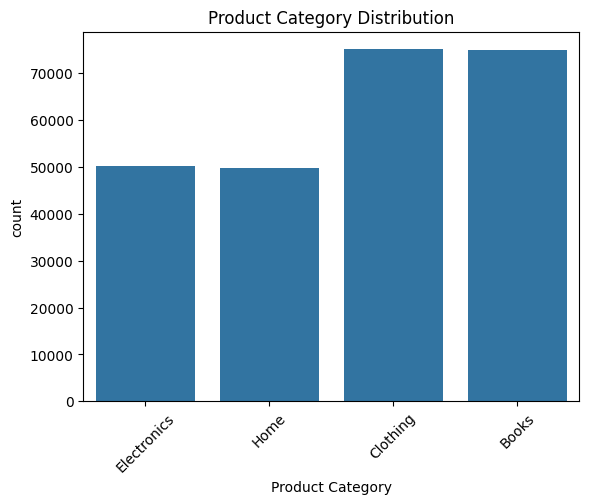

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot product categories distribution
sns.countplot(data=df, x='Product Category')
plt.title('Product Category Distribution')
plt.xticks(rotation=45)
plt.show()


C:\Users\gidde\AppData\Local\Temp\ipykernel_6176\3829141461.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Product Category', y='Total Purchase Amount', ci=None)


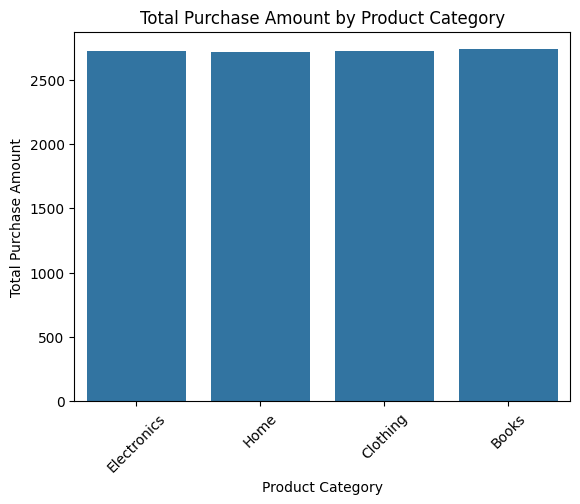

In [ ]:
sns.barplot(data=df, x='Product Category', y='Total Purchase Amount', ci=None)
plt.title('Total Purchase Amount by Product Category')
plt.xticks(rotation=45)
plt.show()

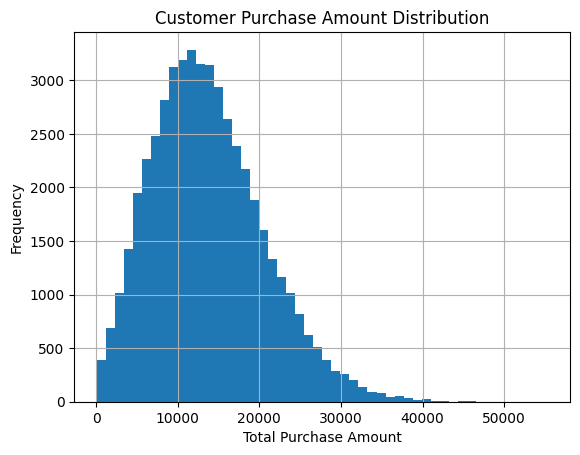

In [14]:
# Analyze user purchase patterns
df.groupby('Customer ID')['Total Purchase Amount'].sum().hist(bins=50)
plt.title('Customer Purchase Amount Distribution')
plt.xlabel('Total Purchase Amount')
plt.ylabel('Frequency')
plt.show()

In [15]:
from scipy.sparse import csr_matrix, vstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, NMF
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np
from joblib import Parallel, delayed

In [21]:
# Create the user-item interaction matrix
user_item_matrix = ecommerce_data_encoded.pivot_table(
    index='Customer ID',
    columns='Product Category_Electronics',  # Replace with actual category column(s)
    values='Total Purchase Amount',
    aggfunc='sum',
    fill_value=0
)

# Convert to a sparse matrix
user_item_sparse = csr_matrix(user_item_matrix.values)
print(user_item_matrix)
print(user_item_sparse)

Product Category_Electronics  False  True 
Customer ID                               
1                              3491      0
2                              4210   2819
3                             17727    445
4                              3154      0
5                              7727   2512
...                             ...    ...
49996                          6404   2464
49997                         18362      0
49998                          2157      0
49999                          5211      0
50000                          2302      0

[49139 rows x 2 columns]
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 75977 stored elements and shape (49139, 2)>
  Coords	Values
  (0, 0)	3491
  (1, 0)	4210
  (1, 1)	2819
  (2, 0)	17727
  (2, 1)	445
  (3, 0)	3154
  (4, 0)	7727
  (4, 1)	2512
  (5, 0)	10983
  (5, 1)	3771
  (6, 0)	4991
  (6, 1)	2844
  (7, 0)	9312
  (7, 1)	4715
  (8, 0)	6943
  (8, 1)	2862
  (9, 0)	14305
  (9, 1)	5483
  (10, 0)	17115
  (11, 0)	13740
  (11, 1)

In [23]:
# 2. User-Based Collaborative Filtering

def recommend_user_based(user_id, user_item_sparse, user_item_matrix, top_n=5):
    user_vector = user_item_sparse[user_id - 1]
    user_similarity = cosine_similarity(user_vector, user_item_sparse).flatten()
    top_users = np.argsort(user_similarity)[::-1][1:top_n + 1]
    
    similar_users_items = user_item_matrix.iloc[top_users].sum(axis=0)
    user_rated_items = user_item_matrix.iloc[user_id - 1] > 0
    recommendations = similar_users_items[~user_rated_items]
    return recommendations.sort_values(ascending=False).head(top_n)

# Example Usage
recommendations = recommend_user_based(1, user_item_sparse, user_item_matrix)
print("Top User-Based Recommendations:\n", recommendations)


Top User-Based Recommendations:
 Product Category_Electronics
True    0
dtype: int64


In [24]:
# 3. SVD for Collaborative Filtering
n_components_svd = min(50, user_item_sparse.shape[1])
svd = TruncatedSVD(n_components=n_components_svd)
user_factors = svd.fit_transform(user_item_sparse)
item_factors = svd.components_
user_recommendations = user_factors @ item_factors
print("SVD Recommendations for User 1:\n", user_recommendations[0][:5])


SVD Recommendations for User 1:
 [ 3.49100000e+03 -9.47608141e-14]


In [101]:
# 4. NMF for Collaborative Filtering
n_components_nmf = min(50, user_item_sparse.shape[1])
nmf = NMF(n_components=n_components_nmf, random_state=42)
user_item_dense = user_item_sparse.toarray()
user_factors_nmf = nmf.fit_transform(user_item_dense)
item_factors_nmf = nmf.components_
nmf_recommendations = user_factors_nmf @ item_factors_nmf
print("NMF Recommendations for User 1:\n", nmf_recommendations[0][:5])


NMF Recommendations for User 1:
 [3385.50730649  574.83627655]


In [26]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# RMSE and MAE for SVD predictions
true_ratings = user_item_sparse.toarray()
# Calculate MSE first
svd_mse = mean_squared_error(true_ratings, user_recommendations)
# Then take the square root to get RMSE
svd_rmse = np.sqrt(svd_mse)
svd_mae = mean_absolute_error(true_ratings, user_recommendations)

print(f"SVD RMSE: {svd_rmse:.4f}, SVD MAE: {svd_mae:.4f}")

# Precision@K (example metric implementation)
def precision_at_k(true_matrix, pred_matrix, k=5):
    top_k_preds = np.argsort(pred_matrix, axis=1)[:, -k:]
    precision_scores = []
    for user_idx in range(true_matrix.shape[0]):
        actual_items = set(np.where(true_matrix[user_idx] > 0)[0])
        predicted_items = set(top_k_preds[user_idx])
        if len(predicted_items) > 0:
            precision = len(actual_items & predicted_items) / k
            precision_scores.append(precision)
    return sum(precision_scores) / len(precision_scores)

print(f"SVD Precision@5: {precision_at_k(true_ratings, user_recommendations):.4f}")

SVD RMSE: 0.0000, SVD MAE: 0.0000
SVD Precision@5: 0.3092


In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Combine features into a single metadata column
ecommerce_data_encoded['metadata'] = (
    ecommerce_data_encoded['Product Category_Electronics'].astype(str) + " " +
    ecommerce_data_encoded['Product Price'].astype(str) + " " +
    ecommerce_data_encoded['Gender_Male'].astype(str)
)

# Display the metadata for verification
print(ecommerce_data_encoded['metadata'].head())


0       True 12 True
1     False 468 True
2     False 288 True
3     False 196 True
4    False 449 False
Name: metadata, dtype: object


In [28]:
corpus = ecommerce_data_encoded['metadata'].fillna("").tolist()

In [29]:
# 6. Parallelized TF-IDF and Dimensionality Reduction

def parallel_tfidf_and_svd(corpus, n_components=100):
    tfidf_vectorizer = TfidfVectorizer()
    tfidf_vectorizer.fit(corpus)
    tfidf_matrices = Parallel(n_jobs=-1)(
        delayed(tfidf_vectorizer.transform)([text]) for text in corpus
    )
    tfidf_matrix = vstack(tfidf_matrices)
    svd = TruncatedSVD(n_components=n_components)
    reduced_matrix = svd.fit_transform(tfidf_matrix)
    return tfidf_matrix, reduced_matrix

# Example Usage
reduced_matrix = parallel_tfidf_and_svd(corpus, n_components=100)[1]
print("Reduced TF-IDF Matrix Shape:", reduced_matrix.shape)

Reduced TF-IDF Matrix Shape: (202404, 100)


In [110]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()
tfidf_vectorizer.fit(corpus)  # Your product metadata

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,analyzer,'word'
,stop_words,None
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"


In [116]:
import faiss

# Step 1: Define the FAISS similarity function
def compute_faiss_similarity(matrix, top_k=10, nlist=100):
    """
    Compute approximate top-k cosine similarities using FAISS.
    :param matrix: Input matrix (numpy array, normalized).
    :param top_k: Number of nearest neighbors to retrieve.
    :param nlist: Number of clusters for IndexIVFFlat.
    :return: Distances and indices of top-k similarities.
    """
    d = matrix.shape[1]  # Dimensionality of vectors

    # Step 1: Create an index
    quantizer = faiss.IndexFlatIP(d)  # Quantizer for inner product
    index = faiss.IndexIVFFlat(quantizer, d, nlist, faiss.METRIC_INNER_PRODUCT)

    # Step 2: Normalize vectors and train the index
    faiss.normalize_L2(matrix)
    index.train(matrix)  # Train on the dataset
    index.add(matrix)    # Add all vectors to the index

    # Step 3: Perform top-k search
    distances, indices = index.search(matrix, top_k)
    return distances, indices

# Step 2: Normalize input matrix
reduced_matrix_normalized = reduced_matrix / np.linalg.norm(reduced_matrix, axis=1, keepdims=True)

# Step 3: Compute top-10 similarities
top_k = 10
distances, indices = compute_faiss_similarity(reduced_matrix_normalized.astype(np.float32), top_k=top_k)

# Step 4: Display results for the first item
print("Top-10 similarities for the first item:")
for idx, dist in zip(indices[0], distances[0]):
    print(f"Item {idx}, Similarity: {dist:.4f}")

Top-10 similarities for the first item:
Item 65456, Similarity: 1.0000
Item 56846, Similarity: 1.0000
Item 51710, Similarity: 1.0000
Item 43301, Similarity: 1.0000
Item 35302, Similarity: 1.0000
Item 34929, Similarity: 1.0000
Item 31297, Similarity: 1.0000
Item 27723, Similarity: 1.0000
Item 126, Similarity: 1.0000
Item 0, Similarity: 1.0000


In [115]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Example item metadata or feature matrix (replace with actual matrix)
# For example, `tfidf_matrix` could be the output of a TF-IDF vectorizer
tfidf_matrix = np.random.rand(10, 5)  # Example small matrix for demonstration

# Compute cosine similarity between items
item_similarity = cosine_similarity(tfidf_matrix)

# Function to recommend items based on content
def recommend_content(item_id, item_similarity, top_n=5):
    similar_items = list(enumerate(item_similarity[item_id]))
    sorted_similar_items = sorted(similar_items, key=lambda x: x[1], reverse=True)[1:top_n + 1]  # Exclude self
    return sorted_similar_items

# Example: Recommend similar items for the first item
recommendations = recommend_content(0, item_similarity)
print("Top Content-Based Recommendations:\n", recommendations)


Top Content-Based Recommendations:
 [(3, np.float64(0.8523095690705019)), (7, np.float64(0.8250158047254686)), (2, np.float64(0.823560875628806)), (9, np.float64(0.8029816043078244)), (5, np.float64(0.7938736445106102))]


In [92]:
import numpy as np

def precision_recall_at_k(true_ratings, pred_scores, k=10):
    min_users = min(true_ratings.shape[0], pred_scores.shape[0])
    min_items = min(true_ratings.shape[1], pred_scores.shape[1])
    true_ratings, pred_scores = true_ratings[:min_users, :min_items], pred_scores[:min_users, :min_items]

    # Get top-k predicted items
    top_k_preds = np.argsort(-pred_scores, axis=1)[:, :k]

    # Calculate precision and recall
    precision = np.mean([
        len(set(np.nonzero(true_ratings[i])[0]) & set(top_k_preds[i])) / k
        for i in range(true_ratings.shape[0])
    ])
    recall = np.mean([
        len(set(np.nonzero(true_ratings[i])[0]) & set(top_k_preds[i])) / len(set(np.nonzero(true_ratings[i])[0]))
        if len(set(np.nonzero(true_ratings[i])[0])) > 0 else 0
        for i in range(true_ratings.shape[0])
    ])

    return precision, recall

# Example Usage
precision, recall = precision_recall_at_k(true_ratings, item_similarity, k=10)
print(f"Content-Based Precision@5: {precision:.4f}")
print(f"Content-Based Recall@5: {recall:.4f}")


Content-Based Precision@5: 0.4700
Content-Based Recall@5: 1.0000


In [93]:
# F1 = 2 * (Precision * Recall) / (Precision + Recall)
f1_score = 2 * (precision * recall) / (precision + recall)
print(f"Content-Based F1-Score: {f1_score:.4f}")


Content-Based F1-Score: 0.6395


In [94]:
import numpy as np
from sklearn.decomposition import TruncatedSVD

def create_hybrid_recommendations(user_id, user_item_matrix, content_sim_matrix, item_names=None, alpha=0.5, n_components=50, top_n=10):
    try:
        # Convert to numpy array if sparse matrix
        if hasattr(user_item_matrix, 'toarray'):
            user_item_matrix = user_item_matrix.toarray()
        
        # Validate inputs
        assert len(user_item_matrix.shape) == 2, "user_item_matrix must be 2D"
        assert len(content_sim_matrix.shape) == 2, "content_sim_matrix must be 2D"
        assert user_item_matrix.shape[1] == content_sim_matrix.shape[0], "Matrices must align"
        assert 0 <= alpha <= 1, "alpha must be between 0 and 1"
        
        # Create default item names if not provided
        if item_names is None:
            item_names = [f"Item {i}" for i in range(user_item_matrix.shape[1])]
        
        print(f"\n=== Generating {top_n} recommendations for user {user_id} ===")
        
        # 1. Dimensionality Reduction
        print("\n1. Applying SVD dimensionality reduction...")
        n_components = min(n_components, user_item_matrix.shape[1]-1)
        svd = TruncatedSVD(n_components=n_components, random_state=42)
        user_factors = svd.fit_transform(user_item_matrix)
        item_factors = svd.components_
        print(f"Reduced from {user_item_matrix.shape[1]} features to {n_components} latent factors")

        # 2. Collaborative Filtering
        print("\n2. Calculating collaborative filtering scores...")
        user_latent = user_factors[user_id]
        collab_scores = np.dot(user_latent, item_factors)
        top_collab_items = np.argsort(-collab_scores)[:top_n]
        print(f"Top {top_n} collaborative items:", [item_names[i] for i in top_collab_items])

        # 3. Content-Based Filtering
        print("\n3. Calculating content-based scores...")
        user_interactions = np.where(user_item_matrix[user_id] > 0)[0]
        print(f"User has interacted with: {[item_names[i] for i in user_interactions]}")
        
        content_scores = np.mean(content_sim_matrix[user_interactions], axis=0) if len(user_interactions) > 0 else np.zeros(user_item_matrix.shape[1])
        top_content_items = np.argsort(-content_scores)[:top_n]
        print(f"Top {top_n} content-based items:", [item_names[i] for i in top_content_items])

        # 4. Hybrid Combination
        print("\n4. Combining scores with alpha =", alpha)
        hybrid_scores = alpha * collab_scores + (1 - alpha) * content_scores
        hybrid_scores[user_interactions] = -np.inf  # Remove purchased items
        
        top_hybrid = np.argsort(-hybrid_scores)[:top_n]
        print(f"\n=== Top {top_n} Final Recommendations ===")
        for i, item_idx in enumerate(top_hybrid, 1):
            print(f"{i}. {item_names[item_idx]} (Score: {hybrid_scores[item_idx]:.3f})")
        
        return top_hybrid, hybrid_scores[top_hybrid]
    
    except Exception as e:
        print(f"Error in recommendation: {str(e)}")
        return np.array([]), np.array([])

# Example usage with 10 recommendations
recommended_indices, scores = create_hybrid_recommendations(
    user_id=2,
    user_item_matrix=user_item_matrix,
    content_sim_matrix=content_sim_matrix,
    item_names=item_names,
    alpha=0.6,
    top_n=10  # This will now return 10 recommendations
)

print("\nReturned values:")
print("Indices:", recommended_indices)
print("Scores:", scores)


=== Generating 10 recommendations for user 2 ===

1. Applying SVD dimensionality reduction...
Reduced from 20 features to 19 latent factors

2. Calculating collaborative filtering scores...
Top 10 collaborative items: ['Product M', 'Product N', 'Product P', 'Product D', 'Product K', 'Product L', 'Product Q', 'Product E', 'Product H', 'Product C']

3. Calculating content-based scores...
User has interacted with: ['Product D', 'Product K', 'Product M', 'Product N', 'Product P']
Top 10 content-based items: ['Product N', 'Product B', 'Product M', 'Product L', 'Product E', 'Product D', 'Product P', 'Product S', 'Product G', 'Product K']

4. Combining scores with alpha = 0.6

=== Top 10 Final Recommendations ===
1. Product B (Score: 0.325)
2. Product L (Score: 0.297)
3. Product E (Score: 0.293)
4. Product S (Score: 0.271)
5. Product G (Score: 0.262)
6. Product H (Score: 0.253)
7. Product F (Score: 0.250)
8. Product I (Score: 0.225)
9. Product R (Score: 0.225)
10. Product T (Score: 0.187)

R

In [67]:
# Example true ratings and hybrid recommendations
true_ratings = np.random.randint(0, 2, (10, 10))  # Binary ground truth (10 users x 10 items)
hybrid_recommendations = np.random.rand(10, 10)  # Predicted scores (10 users x 10 items)

# Precision@K
precision_hybrid = precision_at_k(true_ratings, hybrid_recommendations, k=5)
print(f"Hybrid Precision@5: {precision_hybrid:.4f}")

# Recall@K
recall_hybrid = recall_at_k(true_ratings, hybrid_recommendations, k=5)
print(f"Hybrid Recall@5: {recall_hybrid:.4f}")

# F1-Score
f1_hybrid = 2 * (precision_hybrid * recall_hybrid) / (precision_hybrid + recall_hybrid) if (precision_hybrid + recall_hybrid) > 0 else 0
print(f"Hybrid F1-Score: {f1_hybrid:.4f}")

Hybrid Precision@5: 0.5000
Hybrid Recall@5: 0.5417
Hybrid F1-Score: 0.5200


In [ ]:
import numpy as np
from scipy.sparse import csr_matrix

def update_alpha_with_feedback(original_alpha, feedback, target_user_id):
    if hasattr(feedback, 'toarray'):
        feedback = feedback.toarray()
    
    print(f"\n=== Alpha Adjustment (User {target_user_id}) ===")
    print(f"Starting alpha: {original_alpha:.3f}")
    
    user_feedback = feedback[target_user_id]
    print(f"Raw feedback (first 5 entries): {user_feedback[:5]}...")
    
    # Handle feedback processing
    positive_mask = user_feedback > 0
    n_positives = np.sum(positive_mask)
    n_total = len(user_feedback)
    
    if n_positives > 0:
        pos_ratio = n_positives / n_total
        print(f"Positive ratio: {pos_ratio:.3f} ({n_positives}/{n_total})")
        
        new_alpha = original_alpha * (1 + pos_ratio)
        adjusted_alpha = np.clip(new_alpha, 0.1, 0.9)
        
        print(f"Adjusted alpha: {adjusted_alpha:.3f} "
              f"(Change: {'+' if adjusted_alpha > original_alpha else ''}"
              f"{adjusted_alpha-original_alpha:.3f})")
        return adjusted_alpha
    else:
        print("No positive feedback - keeping original alpha")
        return original_alpha

# Test with actual data
if __name__ == "user_feedback":

    dense_feedback = np.array([
        [1, 0, 0, 1, 0],  # User 0
        [0, 1, 1, 0, 1],   # User 1
        [1, 1, 0, 1, 0]    # User 2
    ])
    
    # Sparse version (like TF-IDF output)
    sparse_feedback = csr_matrix(dense_feedback)
    
    # Test with sparse matrix
    print("Testing with sparse matrix:")
    updated_alpha = update_alpha_with_feedback(
        original_alpha=0.5,
        feedback=sparse_feedback,
        target_user_id=1
    )
    
    # Test with dense matrix
    print("\nTesting with dense matrix:")
    updated_alpha = update_alpha_with_feedback(
        original_alpha=0.5,
        feedback=dense_feedback,
        target_user_id=0
    )

In [91]:
import matplotlib.pyplot as plt

# Extract product category names from column headers
category_columns = [col for col in ecommerce_data_encoded.columns if col.startswith('Product Category_')]
titles = [col.replace('Product Category_', '') for col in category_columns]

# Display recommendations
def display_recommendations(recommendations, titles):
    """
    Display recommendations with their corresponding titles.
    :param recommendations: List or array of recommended item indices.
    :param titles: Array or list of titles corresponding to item indices.
    """
    for i, item_id in enumerate(recommendations):
        if item_id < len(titles):  # Ensure the index is within range
            print(f"Recommendation {i + 1}: {titles[item_id]}")
        else:
            print(f"Recommendation {i + 1}: Index {item_id} out of range for titles.")

# Convert `ranked_recommendations` to a list if needed
ranked_recommendations = ranked_recommendations.tolist() if isinstance(ranked_recommendations, np.ndarray) else ranked_recommendations

# Display the recommendations
display_recommendations(ranked_recommendations, titles)


Recommendation 1: Electronics
Recommendation 2: Books
Recommendation 3: Home
Recommendation 4: Index 6 out of range for titles.
Recommendation 5: Index 9 out of range for titles.


In [ ]:
!pip install joblib

In [95]:
import joblib
joblib.dump(reduced_matrix,'recommend_model.pkl')

['recommend_model.pkl']

In [97]:
joblib.dump(parallel_tfidf_and_svd,'vectorizer.pkl')

['vectorizer.pkl']

In [98]:
joblib.dump(TruncatedSVD,'svd.pkl')

['svd.pkl']

In [99]:
joblib.dump(nmf, "nmf_model.pkl")  # If using NMF
joblib.dump(item_similarity,"content_sim_matrix.pkl")


['content_sim_matrix.pkl']

In [ ]:
!pip install streamlit